 <img align="left" width="75" height="75"  src="https://upload.wikimedia.org/wikipedia/en/c/c8/University_of_the_Punjab_logo.png"> 

<h1 align="center">Department of Data Science</h1>
<h1 align="center">Course: Tools and Techniques for Data Science</h1>

---
<h3><div align="right">Instructor: Muhammad Arif Butt, Ph.D.</div></h3>    

<h1 align="center">Lecture 6.27 (Naïve Bayes' Classifiers using Scikit-Learn)</h1>

<a href="https://colab.research.google.com/github/arifpucit/data-science/blob/master/Section-4-Mathematics-for-Data-Science/Lec-4.1(Descriptive-Statistics).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <img align="center" width="900" src="images/ml-topimg1.png"  >

## Learning agenda of this notebook
- Naïve Bayes' Classifier (A Recap)
- Scikit-Learn's Family of Naïve Bayes' Classifiers
    - GaussianNB
    - BernoulliNB
    - MultinomialNB
    - ComplementNB
    - CategoricalNB
- Example 1: Gaussian Naïve Bayes' (`GaussianNB`)
- Example 2: (`MultinomialNB`)
- Tasks to Do

# 1. Naïve Bayes' Classifier (A Recap)
<h3 align="center"><div class="alert alert-success" style="margin: 20px">
The Naïve Bayes' (NB) is a probabilistic machine learning algorithm that use Bayes’ Theorem for supervised machine learning classification.
</h3>


### Bayes' Theorem:
<font face = "Courier New" color=green size=6>$$     P(y=k \mid X) \hspace{0.5cm} = \hspace{0.5cm}  \frac{P(y=k) \times P(X \mid y=k)}{P(X)}, \hspace{0.5cm} P(X)\neq 0 \hspace{0.5cm} $$</font>



### Naïve Bayes' Classifier:
    
<font face = "Courier New" color=magenta size=6>$$     P(y=k \mid x_1,x_2,x_3,...x_m)  \hspace{0.4cm} = \hspace{0.4cm}\hat{y} \hspace{0.4cm} = \hspace{0.4cm}argmax_y P(y=k) * \prod_{i = 1}^{m} P(x_i \mid y=k)\hspace{6cm}$$</font>
    

- The `Naïve Bayes' Classifier` (like Logistic Regression and Neural Network) is **Probabilistic Classifier**, i.e., it output probability estimates for the `k classes`, and then assign a label to the input sample based on these probabilities (typically the label of the class with the highest probability).
- Unlike Naïve Bayes'Classifier `KNN`, `SVM` and `Decision Tree` are **Deterministic classifiers**, i.e., they output a hard label for each sample, without providing probability estimates for the classes. 
- The Naïve Bayes' classifier is called **naïve** because it assumes that the input variables/features are independent of each other, which is rarely the case. In other words, changing the value of one feature, does not directly change the value of any of the other features. This assumption is naïve because it is almost never true.
- Even though Naïve Bayes' is Naïve, it performs very well in applications, even when the features are not idependent of each other. 
- Further more, compared to other ML algorithms, NB is fast, so it could be used for making predictions in real time.
- The Naïve Bayes' classifier performs very well in applications like `sentiment analysis`, `classification of spam emails`, `recommendation systems`, `article categorization`, `search engines` and so on.

# 2. Scikit-Learn's Family of Naïve Bayes' Classifiers


<font face = "Courier New" color=green size=4>from sklearn.</font><font face = "Courier New" color=blue size=4>naive_bayes</font> <font face = "Courier New" color=green size=4> import </font><font face = "Courier New" color=magenta size=5>GaussianNB, BernoulliNB, MultinomialNB</font><br>
  
<font face = "Courier New" color=green size=4>from sklearn.</font><font face = "Courier New" color=blue size=4>naive_bayes</font> <font face = "Courier New" color=green size=4> import </font><font face = "Courier New" color=magenta size=5>ComplementNB, CategoricalNB</font><br>





<img align="center" width="1200"  src="images/nb-classifier-typesb.png"  > 
<br><br>
<font face = "Arial" color=red size=3>
<li>ComplementNB is an extension of MultinomialNB, which is more suitable in case of imbalanced datasets and often outperform  MultinomialNB on text classification tasks. </li><br>
    
<font face = "Arial" color=green size=3>
<li> CategoricalNB is useful if the features are categorically distributed. For this we normally encode the categorical variables in numeric format using the ordinal encoder.</li>
    
</font>

# 3. Example 1: Gaussian Naïve Bayes' (`GaussianNB`)

## a. Load Breast Cancer Dataset
- Load this dataset using `load_breast_cancer()` method of `sklearn.datasets` module.
- Load this dataset using `fetch_openml()` method of `sklearn.datasets` module.
- Download this dataset from UCI ML Breast Cancer Wisconsin (Diagnostic) datasets, and then use `read_csv()` method.

In [1]:
import pandas as pd
df = pd.read_csv('datasets/breast_cancer.csv')
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0.0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0.0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0.0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0.0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0.0


In [2]:
df.shape

(569, 31)

In [3]:
from sklearn import datasets
bunch = datasets.load_breast_cancer()
print(bunch.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of concave portions of the contour)
        - concave points (number of concave portions of the contour)
        - symmetry
        - fractal dimension ("coastline approximation" - 1)

        The mean, standard error, and "worst" or largest (mean of the three
        worst/largest values) of these features were computed for each image,
        resulting in 30 features.  For instance, field 0 is Mean Radi

In [4]:
df['target'].value_counts()

1.0    357
0.0    212
Name: target, dtype: int64

`Class Distribution:`<br>
    - 212: Malignant (0)<br>
    - 357: Benign (1)

## b. Exploratory Data Analysis


Since EDA has no real set methodolgy, the following is a short check list you might want to walk through:

1. What question(s) are you trying to solve (or prove wrong)?
2. What’s missing from the data and how do you deal with it?
3. Are there any outliers and how to treat them?
4. What kind of data do you have and how do you treat different types?
5. How can you add, change or remove features to get more out of your data?
6. How your data is distributed and the correlation between different variables?

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [6]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


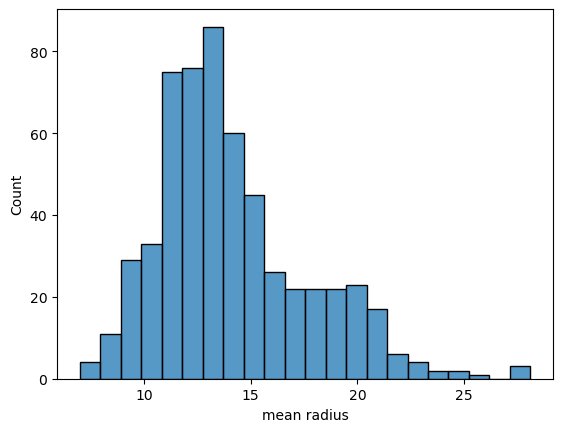

In [7]:
import seaborn as sns
sns.histplot(data=df, x='mean radius');

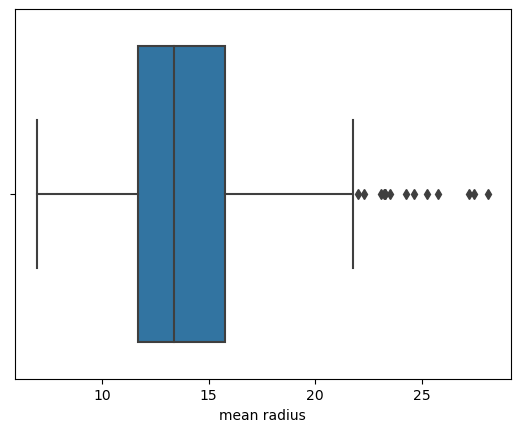

In [8]:
sns.boxplot(data=df, x='mean radius');

## c. Data Preprocessing and Feature Engineering

- `Data Preprocessing` involves actions that we need to perform on the dataset in order to make it ready to be fed to the machine learning model.
- `Feature Engineering` is the process of using domain knowledge to extract features from raw data via data mining techniques.<br>
    
    <font face = "Garamond" color=green size=4>**a. Detecting and handling outliers** </font>

    <font face = "Garamond" color=green size=4>**b. Missing values Imputation** </font>

    <font face = "Garamond" color=green size=4>**c. Encoding Categorical Features**</font>
   
    <font face = "Garamond" color=green size=4>**d. Feature Scaling** </font>

    <font face = "Garamond" color=green size=4>**e. Extracting Information** </font>
    
    <font face = "Garamond" color=green size=4>**f. Combining Information** </font>
    


### (i) Missing Value Imputation
- **Why do we need to handle missing values?** 
    - If the missing values are not handled properly, you may end up building a biased machine learning model which will lead to incorrect results.
    - Many machine learning algorithms fail if the dataset contains missing values. However, algorithms like K-nearest and Naive Bayes support data with missing values.

- **How to treat missing values?**
    - Analyze each column with missing values carefully to understand the reasons behind the missing values as it is crucial to find out the strategy for handling the missing values. There are 2 primary ways of handling missing values:
        - Deleting the Missing values: Drop rows (List-wise deletion) having missing values or drop the entire column
        - Imputing the Missing Values: Replace the missing value with a value
            - `Univariate Imputation` 
                - Handling Missing Values using Panda's `fillna()` method
                - Handling Missing Values using sklearn's `SimpleImputer()` transformer
                - Use of Column Transformer
            - `Multivariate Imputation`
                - Handling Missing Values using sklearn's `IterativeImputer()` transformer 
                - Handling Missing Values using sklearn's `KNNImputer()` transformer  
<br><br>        
<img align="center" width="1000" src="images/imputer4.png"  >

<br><br>
<font face = "Arial" color=magenta size=4>**Note:** Naïve Bayes' Classifier Models handle missing values at their own, so there is no need to impute missing values if you are using Naive Bayes'.</font>

<font face = "Courier New" color=magenta size=5>$$     P(y=k \mid x_1,x_2,x_3,...x_m)  \hspace{0.4cm} = \hspace{0.4cm}\hat{y} \hspace{0.4cm} = \hspace{0.4cm}argmax_y P(y=k) * \prod_{i = 1}^{m} P(x_i \mid y=k)\hspace{6cm}$$</font>
- In the above formula, simply ignore the $P(x_i \mid y=k)$ where the input feature vector has missing value.

### (ii) Encoding Categorical Features
    
<center><h4 align="center"><div class="alert alert-success" style="margin: 20px">Encoding categorical data is a process of converting it into numerical values, so that it could be fed to machine learning models</h4></center>

<img align="center" width="900" src="images/encoders1.png"  >
    
<br><br>
<font face = "Arial" color=magenta size=4>**Note:** For textual data (NLP), there exist many encoding techniques, however, today we will use Bag of Words (BoW) and Term Frequency - Inverse Document Frequency (TFIDF) encoding</font>

### (iii) Feature Scaling

<center><h3 align="center"><div class="alert alert-success" style="margin: 20px">Feature scaling is a process of transforming numeric columns to a common scale</h3></center> 
    
<img align="center" width="1000" src="images/scaling-how2.png"  >  
    
- **Normalization** is rescaling of the data from original range, so that all values are within the new range of 0 and 1.
- **Standardization** is rescaling of the data from original range, so that all values are centered around mean with a standard deviation of 1.
- `Note:` 
    - After scaling the distribution of data does not change.
    - Use standardization if your data is normally distributed, otherwise, use normalization
    - Standardization is more robust to outliers.
    
<br><br>
<font face = "Arial" color=magenta size=4>**Note:** Since Naïve Bayes' classifier is not dependent on distance, so feature scaling is not required as such. However, feature scaling is a must to do for distance based algorithms like Linear/Logistic Regression, KNN, and SVM</font>

### (iv) Handling Outliers
<center><h3 align="center"><div class="alert alert-success" style="margin: 20px">An outlier is a data point that differs significantly from other observations</h3></center>

- **How to identify outliers?**
    - `Z Score Method:` $ x_i < \mu - 3\sigma \hspace{.5cm}\text{OR}\hspace{.5cm} x_i > \mu + 3\sigma $
    - `IQR Method`
    - `Percentiles Method`
    - Multivariate Analysis using Scatter Plot

<img align="center" width="800" src="images/outliers.png"  >

- **How to treat outliers?**
    - `Trimming`
    - `Capping/Winsorization`
    - `Discretization` 
    
<br><br>
<font face = "Arial" color=magenta size=4>**Note:** Naïve Bayes' classifier is highly sensitive to outliers. In Gaussian Naïve Bayes', outliers will affect the mean and variance. In Binomial Naïve Bayes' (text data) a simple hack is not to consider the word, if it occur very seldom in the training set. OR use Laplace Smoothing</font>

## d. Do a Train-Test Split and Train the `GaussianNB` Model

In [9]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0.0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0.0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0.0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0.0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0.0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0.0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0.0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0.0


**Train Test Split:**

In [10]:
from sklearn.model_selection import train_test_split
X = df.drop('target', axis=1) # df.iloc[:, 0:-1]
y = df['target']              # df.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 555, shuffle=True)
X.shape, y.shape, X_train.shape, X_test.shape, y_train.shape,  y_test.shape

((569, 30), (569,), (455, 30), (114, 30), (455,), (114,))

**Create Instance of `GaussianNB` Model:**

In [11]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()

**Train the `GaussianNB` Model:**<br>
- Gaussian Naive Bayes' is not a lazy learning model rather a eager/generative model.
- It therefor, calculate Sample Mean and Standard Deviation of Cancer and Healthy Groups and use following probability density function of Gaussian Distribution to calculate all the pdf values for the training dataset:

<font face = "Arial" color=magenta size=4> $$f(x) = \frac{1}{\sqrt{2\pi \sigma^2} }\hspace{0.4cm}\large e^{-\frac{(x-\mu)^2}{2\sigma^2}} $$ </font>


In [12]:
model.fit(X_train, y_train)

GaussianNB()

**Carry out the Prediction on the test data`GaussianNB` Model:**
- During the prediction phase, `GaussianNB` uses the above calculated pdf values (during the training phase) to calculate the probabilities of the new unseen data without requiring the original training data at prediction time. That is why we say that it is not lazy rather a generative model.
<br><br>
<font face = "Courier New" color=green size=4>$P(y=0 \mid x_1=\text{mean_radius},x_2=\text{mean_texture}, \cdots x_{30}=\text{worst_fractal_dimension}) \hspace{0.5cm}$</font>
<br><br>
<font face = "Courier New" color=green size=4>$P(y=1 \mid x_1=\text{mean_radius},x_2=\text{mean_texture}, \cdots x_{30}=\text{worst_fractal_dimension}) \hspace{0.5cm}$</font>


In [13]:
# predict_proba() method returns the two posterior probabilities of all observations of test dataset 
# of belonging to class 0 (Malignant) or class 1 (Benign)
model.predict_proba(X_test)

array([[9.99999448e-001, 5.52293909e-007],
       [3.14186060e-018, 1.00000000e+000],
       [1.00000000e+000, 2.50150354e-014],
       [9.58401522e-016, 1.00000000e+000],
       [1.00000000e+000, 8.12165985e-084],
       [8.58120716e-015, 1.00000000e+000],
       [2.97310809e-013, 1.00000000e+000],
       [9.05377360e-010, 9.99999999e-001],
       [4.87716806e-012, 1.00000000e+000],
       [1.06360810e-015, 1.00000000e+000],
       [1.61611977e-014, 1.00000000e+000],
       [9.99999618e-001, 3.81647463e-007],
       [6.64735693e-016, 1.00000000e+000],
       [1.66878748e-012, 1.00000000e+000],
       [1.13924670e-016, 1.00000000e+000],
       [7.01370955e-010, 9.99999999e-001],
       [3.65865963e-019, 1.00000000e+000],
       [8.20473748e-012, 1.00000000e+000],
       [1.86164253e-018, 1.00000000e+000],
       [2.32606137e-020, 1.00000000e+000],
       [4.92473752e-005, 9.99950753e-001],
       [1.00000000e+000, 1.24249178e-245],
       [1.00000000e+000, 2.97272191e-042],
       [9.9

<font face = "Courier New" color=magenta size=4>$     P(y=k \mid x_1,x_2,x_3,...x_n)  \hspace{0.5cm} = \hspace{0.5cm}\hat{y} \hspace{0.5cm} = \hspace{0.5cm}argmax_y P(y=k) * \prod_{i = 1}^{m} P(x_i \mid y=k)\hspace{6cm}$</font>

In [14]:
# predict() method use the argmax function to  returns the labels as  class 0 (Malignant) or class 1 (Benign)
# This is the Maximum A-Posteriori or MAP decision rule
y_pred = model.predict(X_test)
y_pred

array([0., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 0., 0., 0., 1., 1., 0., 0., 1., 0., 1., 1., 0., 0.,
       1., 1., 1., 0., 1., 0., 0., 1., 0., 0., 1., 1., 0., 1., 1., 1., 0.,
       1., 0., 0., 1., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 0., 0., 0., 1., 1., 1., 1., 0., 1., 0., 0., 1., 1., 0., 1.,
       0., 1., 0., 0., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 0., 0.,
       0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1., 1.])

In [15]:
# Ground labels of test dataset
y_test.values

array([1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 1.,
       1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 0., 1., 0., 1., 1., 0., 1.,
       1., 1., 1., 0., 1., 0., 0., 1., 0., 0., 1., 1., 0., 1., 1., 1., 0.,
       1., 0., 0., 1., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 0., 1., 0., 0., 1.,
       0., 0., 0., 0., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 0., 0.,
       0., 1., 1., 1., 0., 1., 0., 1., 0., 0., 1., 1.])

## e. Model Evaluation

<img align="right" width="500"  src="images/model-evaluation.jpeg"  > 

- Model evaluation is the process of using different evaluation metrics to understand a machine learning model's performance, as well as its strengths and weaknesses
- **Evaluation Metrics for Classification Algorithms:**
    - Confusion Matrix
    - Accuracy
    - Precision
    - Recall
    - F1-Score
    - AUC-ROC (Receiver Operator Characteristic (ROC) curve
- **Evaluation Metrics for Regression Algorithms:**
    - Mean Absolute Error (MAE)
    - Mean Squared Error (MSE)
    - Root Mean Squared Error (RMSE)
    - R-Squared (coefficient of determination)
    - Adjusted R-Squared

**Confusion Matrix:**

Confusion Matrix:
 [[37  8]
 [ 4 65]]


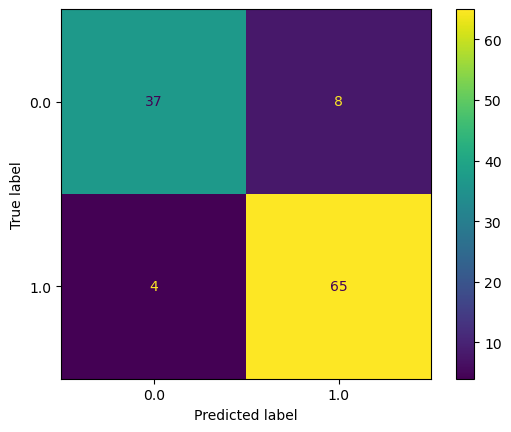

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred);
#ConfusionMatrixDisplay.from_estimator(model, X_test, y_test);

**Evaluation Metrics:**

$\text{Accuracy} \hspace{0.5cm} = \hspace{0.5cm} \large \frac{TP + TN}{TP + TN + FP + FN}$

$\text{Precision} \hspace{0.5cm} = \hspace{0.1cm} \large \frac{TP}{TP + FP}$


$\text{Recall} \hspace{0.9cm} = \hspace{0.1cm} \large \frac{TP}{TP + FN}$

$ F1 \hspace{1.4cm} = \hspace{0.1cm} \large \frac{2}{\frac{1}{P}+\frac{1}{R}} \hspace{0.6cm} \small= \hspace{0.1cm} \large \frac{2PR}{P+R}$


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy score: ", accuracy)
print("Precision score: ", precision)
print("Recall score: ", recall)
print("F1 score: ", f1)
print("\n Classification Report:\n", classification_report(y_test, y_pred))

Accuracy score:  0.8947368421052632
Precision score:  0.8904109589041096
Recall score:  0.9420289855072463
F1 score:  0.9154929577464788

 Classification Report:
               precision    recall  f1-score   support

         0.0       0.90      0.82      0.86        45
         1.0       0.89      0.94      0.92        69

    accuracy                           0.89       114
   macro avg       0.90      0.88      0.89       114
weighted avg       0.90      0.89      0.89       114



- We use <b>`macro average` precision/recall/f1-score</b> when we want to give an `equal weight to each class`.
- We use <b>`micro average` precision/recall/f1-score</b> when we want to give an `equal weight to each instance`.
<center><font face = "Garamond" color=blue size=4><b>macro weighs each class equally</b> whereas <b>micro weighs each sample equally</b>.</font></center>
- We use <b>`weighted average` precision/recall/f1-score</b> when we want to assign greater contribution to classes with more number of samples in the dataset

# 4. Example 2: (`MultinomialNB`)
## a. Load Dataset
<h3 align="center"><div class="alert alert-success" style="margin: 20px">NLP enable computers to understand/respond human language(s) in written/verbal/sign form</h3>
    
Arif NLP Videos: https://www.youtube.com/playlist?list=PL7B2bn3G_wfANUMx-dOv_qACGKchtDWum

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

data = pd.read_csv('datasets/text-data.csv')
data

,document,label
0,Arif youTube lectures are amaizing,positive
1,This is an amaizing place,positive
2,I do not like this restaurant,negative
3,Arif youTube lectures are great,positive
4,"I cannot deal with this, you deal with this",negative
5,This is my best work,positive
6,What an awesome view,positive
7,I am tired of this stuff,negative
8,He is my sworn enemy,negative
9,My boss is horrible,negative


In [19]:
data.shape

(18, 2)

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   document  18 non-null     object
 1   label     18 non-null     object
dtypes: object(2)
memory usage: 416.0+ bytes


**Encode the Output Label Column:**
- Use either `map()` method or `LabelEncoder`
- Label Encoding is a popular encoding technique for handling categorical variables, which assign each category value a unique integer starting from 0 to n-1 based on alphabetical ordering

In [21]:
# Use map() method to encode the output label
data['numericlabel1'] = data.label.map({'positive':1, 'negative':0})
data

,document,label,numericlabel1
0,Arif youTube lectures are amaizing,positive,1
1,This is an amaizing place,positive,1
2,I do not like this restaurant,negative,0
3,Arif youTube lectures are great,positive,1
4,"I cannot deal with this, you deal with this",negative,0
5,This is my best work,positive,1
6,What an awesome view,positive,1
7,I am tired of this stuff,negative,0
8,He is my sworn enemy,negative,0
9,My boss is horrible,negative,0


In [22]:
# Use LabelEncoder transformer class to encode the output label
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['numericlabel2'] = le.fit_transform(data.iloc[:, 1])
data

,document,label,numericlabel1,numericlabel2
0,Arif youTube lectures are amaizing,positive,1,1
1,This is an amaizing place,positive,1,1
2,I do not like this restaurant,negative,0,0
3,Arif youTube lectures are great,positive,1,1
4,"I cannot deal with this, you deal with this",negative,0,0
5,This is my best work,positive,1,1
6,What an awesome view,positive,1,1
7,I am tired of this stuff,negative,0,0
8,He is my sworn enemy,negative,0,0
9,My boss is horrible,negative,0,0


In [23]:
# Save the sentences/documents in variable X
X=data.document
X

0              Arif youTube lectures are amaizing
1                       This is an amaizing place
2                   I do not like this restaurant
3                 Arif youTube lectures are great
4     I cannot deal with this, you deal with this
5                            This is my best work
6                            What an awesome view
7                        I am tired of this stuff
8                            He is my sworn enemy
9                             My boss is horrible
10                       This is an awesome place
11          I do not like the taste of this juice
12                            I love to do hiking
13              I am sick and tired of this place
14                           What a great holiday
15                 That is a bad locality to stay
16                 We will have good fun tomorrow
17                 I went to my enemy house today
Name: document, dtype: object

In [24]:
# Save the output label in variable y
y = data.numericlabel1
y

0     1
1     1
2     0
3     1
4     0
5     1
6     1
7     0
8     0
9     0
10    1
11    0
12    1
13    0
14    1
15    0
16    1
17    0
Name: numericlabel1, dtype: int64

# b. Text Pre-Processing

<img align="right" width="600" src="images/text-preprocessing.png"  >

- **Text Cleaning:** 
    - Removing digits and words containing digits
    - Removing newline characters and extra spaces
    - Removing HTML tags
    - Removing URLs
    - Removing punctuations
    - Handle emojis
    - Spelling correction

- **Basic Preprocessing:** 
    - Case folding
    - Expand contractions
    - Chat word treatment
    - Spelling correction
    - Tokenization and N-grams
    - Removing stop words

- **Advance Preprocessing:**
    - Stemming (Porter Stemmer, Snowball Stemmer, Lancaster Stemmer, Regex-based Stemmer)
    - Lemmatization
    - POS tagging
    - Parsing
    - Coreference Resolution
    
<font face = "Arial" color=magenta size=5>$\hspace{2cm}$ re, nltk, spacy, gensim, textblob, wordcloud, contractions, clean-text, emoji </font>   


**Basic Text Preprocessing:** https://www.youtube.com/watch?v=8PTEaCI5GTU&list=PL7B2bn3G_wfANUMx-dOv_qACGKchtDWum&index=2


**Advance Text Preprocessing:** https://www.youtube.com/watch?v=OIria2ylIbY&list=PL7B2bn3G_wfANUMx-dOv_qACGKchtDWum&index=3

|Stemming|Lemmatization
|:------|:------
|Stemming is faster because it chops words without knowing the context of the word in given sentences.|Lemmatization is slower as compared to stemming but it knows the context of the word before proceeding.
|It is a rule-based approach.|It is a dictionary-based approach.
|Accuracy is less.|Accuracy is more as compared to Stemming.
|When we convert any word into root-form then stemming may create the non-existence meaning of a word.|Lemmatization always gives the dictionary word while converting into root-form.
|Stemming is preferred when the meaning of the word is not important for analysis. Example: Spam Detection|Lemmatization would be recommended when the meaning of the word is important for analysis. Example: Question Answer
|For Example: “Studies” => “Studi”|For Example: “Studies” => “Study”

# c. Feature Engineering / Text Vectorization (What, Why and How?)

<h3 align="center" style="font-family:'Courier New'"> <div class="alert alert-info" style="margin: 20px">A feature in NLP can be a single word in your text, or can be a phrase, a sentence, a paragraph or may be a complete document</h3>

    
<h3 align="center" style="font-family:'Courier New'"> <div class="alert alert-info" style="margin: 20px">The process of converting text data into vectors of real numbers is called Text Vectorization</h3>

<img align="center" width="900"  src="images/feature-engr-models.png"  > 

- The two main categories and their sub-categories of word embeddings are:
    - **Frequency Based Word Embedding Techniques:**
        - Label Encoding
        - One-Hot encoding
        - Bag of Words (BoW)
        - Bag of n-grams
        - Term Frequency - Inverse Document Frequency (TFIDF)
        - Global Vectors (GloVe)
    - **Prediction Based Word Embedding Techniques:**
        - Word2Vec (Google, 2013)
        -  FastText (Facebook, 2016)
        
**Feature Engineering:** https://www.youtube.com/watch?v=CUXc-caMKw8&list=PL7B2bn3G_wfANUMx-dOv_qACGKchtDWum&index=4

# (i) <span style='background :lightgreen' > Label Encoding </span>

- A `Document` is a single text data point. For Example, a tweet, a youtube comment or a review of a particular product by the user.
- A `Corpus` is a collection of all the documents present in our dataset.
- A `Feature` is every unique word in the corpus.
- Consider the following corpus that consists of three documents:
<h3 align="left" style="font-family:'Courier New'">doc1=["Arif help his students"]</h3>
<h3 align="left" style="font-family:'Courier New'">doc3=["Arif assist his students"]</h3>
<h3 align="left" style="font-family:'Courier New'">doc3=["Arif lectures are great"]</h3>


- Build a vocabulary of your corpus and assign a unique number to each word as shown below:

<h3 align="left" style="font-family:'Courier New'">vocab = {1:'students', 2:'assist', 3:'his', 4:'help', 5:'Arif', 6:'lectures', 7:'great', 8:'are'}</h3>

- To vectorize, you simply represent every word of a document with a number by a simple look-up from the dictionary above, as shown below:

<h3 align="left" style="font-family:'Courier New'">doc1=["Arif help his students"] = [5, 4, 3, 1]</h3>

<h3 align="left" style="font-family:'Courier New'">doc2=["Arif assist his students"] = [5, 2, 3, 1]</h3>

<h3 align="left" style="font-family:'Courier New'">doc3=["Arif lectures are great"] = [5, 6, 8, 7]</h3>

### Limitations of Label Encoding:
- **`Size is not Fixed`:** Consider a new document (`Arif students are great help`) that we need to classify. Once you will vectorize this document the size of the vector representing this document will be 5 instead of 4. Unfortunately, our machine learning algorithms, expect same/fixed size input, and therefore we will not be able to process it.
- **`Out of Vocabulary Problem (OOV)`:** Consider a new document (`Arif youTube lectures are great`). It has a new word "youTube", that is not there in the vocabulary. So we will not be able to encode it. This is called out of vocabulary (OOV) problem.
- **`Cannot Capture Semantics/Meanings`:** The word "help" and "assist" are almost similar in meaning, but these two words have completely different representations in label encoding. 


<center><font face = "Garamond" color=red size=4>Due to these limitations, Label Encoding is not used for transforming text data into numbers in any of the NLP applications</font></center>

# (ii) <span style='background :lightgreen' > One-Hot Encoding </span>
    
- Consider the following corpus that consists of three documents and the corresponding vocabulary of the corpus:
<h3 align="left" style="font-family:'Courier New'">doc1=["Arif help his students"]</h3>
<h3 align="left" style="font-family:'Courier New'">doc3=["Arif assist his students"]</h3>
<h3 align="left" style="font-family:'Courier New'">doc3=["Arif lectures are great"]</h3>

<h3 align="left" style="font-family:'Courier New'">vocab = {'students', 'assist', 'his', 'help', 'Arif', 'lectures', 'great', 'are'}</h3>

- Encode every word as a binary vector of same size as the number of words in the vocabulary, with only one location having a value of 1, and that is under that word. 
- The columns in the following matrix are the words in the vocabulary, while rows are the words with their vector representation:


<img align="center" color=red width="800"  src="images/one-hot.png"  > 

- In One-Hot Encoding, you represent every word of a document as a vector of size `v`, where `v` is the size of vocabulary. 
- The vectorization of the three documents using one-hot encoding is a sparse matrix as shown below:

<h3 align="left" style="font-family:'Courier New'">doc1=["Arif help his students"] = [[00001000],   [00010000],   [00100000],  [10000000]]</h3>

<h3 align="left" style="font-family:'Courier New'">doc2=["Arif assist his students"] = [[00001000],   [01000000],   [00100000],  [10000000]]</h3>

<h3 align="left" style="font-family:'Courier New'">doc3=["Arif lectures are great"] = [[00001000 ],  [00000001],   [00000010],  [00000100]]</h3>

### Limitations of One Hot Encoding:
- **`Size is not Fixed`:** Consider a document (`Arif students are great help`) that we need to classify. Once you will vectorize this document the size of the sparse matrix representing this document will be (5,8), i.e., 40 numbers. Unfortunately, our machine learning algorithms, expect same/fixed size input, and therefore we will not be able to process it.
- **`Out of Vocabulary Problem (OOV)`:** Consider a document (`Arif youTube lectures are great`). It has a new word "youTube", that is not there in the vocabulary. So we will not be able to encode it. This is called out of vocabulary (OOV) problem.
- **`Cannot Capture Semantic Meanings`:** The word "help" and "assist" are almost similar in meaning, but these two words have completely different representations in one-hot encoding. 
- **`Sparse Matrix Representation`:** This technique is memory hungry. For example in above toy example, each document is represented by a sparse matrix of size (4,8), i.e., 32 numbers out of which 28 are zero.


<center><font face = "Garamond" color=red size=4>Due to these limitations, One-Hot Encoding is not used for transforming text data into numbers in any of the NLP applications</font></center>

# (iii) <span style='background :lightgreen' > Bag of Words (BoW) Encoding </span>

<font face = "Courier New" color=magenta size=4>doc1=["Arif youTube lectures are amaizing"]</font><br>
<font face = "Courier New" color=magenta size=4>doc2=["I like youTube lectures and Khurram also like youTube lectures"]</font><br>
<font face = "Courier New" color=magenta size=4>doc3=["Arif youTube lectures are great"]</font><br><br>
<font face = "Courier New" color=green size=4>vocab = {'also': 0, 'amaizing': 1, 'and': 2, 'are': 3, 'arif': 4, 'great': 5, 'khurram': 6, 'lectures': 7, 'like': 8, 'youtube': 9}</font>

>- **`Document-Term Matrix (DTM)`**, is a mathematical matrix that describes the frequency of terms that occur in a collection of documents and irrespective of the size, each document is converted into a v-dimensional **` frequency vector`**, where `v` is the size of vocabulary.

<img align="center" color=red width="500"  src="images/bow-dtma.png"  > 

<font face = "Courier New" color=blue size=4>doc1=[0,1,0,1,1,0,0,1,0,1]</font><br>

<font face = "Courier New" color=blue size=4>doc2= [1,0,1,0,0,0,1,2,2,2]</font><br>

<font face = "Courier New" color=blue size=4>doc3= [0,0,0,1,1,1,0,1,0,1]</font>

<center><font face = "Garamond" color=green size=4>The main advantage of Bag of Words Encoding over Label or One Hot Encoding is that using BoWs we encode every document as a fixed size vector, irrespective of the number of words in that document. In above corpus, each document is represented as a fixed size vector of size 10, so it can easily be fed to a machine learning model</font></center>

## - Creating Bag of Words using Scikit-Learn's  `CountVectorizer` Class
- **Steps to Programmatically create a DTM using BoW Encoding:**
    -  `Step 1:` Tokenize all the Documents/Sentences in the corpus.
    -  `Step 2:` Create vocabulary of unique words sorted in alphabetical order.
    -  `Step 3:` Populate the cells of the DTM with integer values representing the frequency of words of vocabulary in a particular document.

In [ ]:
X

- **Scikit-learn’s CountVectorizer** The `CountVectorizer` computes the frequency of occurrence of a word in a document. It converts the corpus of multiple documents (say product reviews) into a Document Term Matrix (a sparce matrix). It also allows you to:
    >- control your n-gram size, 
    >- perform custom preprocessing, 
    >- perform custom tokenization, 
    >- eliminate stop words and 
    >- limit vocabulary size.


<h3 align="center" style="font-family:'Courier New'">cv = sklearn.feature_extraction.text.CountVectorizer(arg1, arg2, ...., arg16)</h3>

In [25]:
# create an object of countvectorizer class
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()  
type(cv)

sklearn.feature_extraction.text.CountVectorizer

In [26]:
bow = cv.fit_transform(X) # generates vocabulary dictionary and returns a sparse matrix
bow

<18x55 sparse matrix of type '<class 'numpy.int64'>'
	with 93 stored elements in Compressed Sparse Row format>

>- The bag of words (bow) contains 18 rows as there are 18 sentences/documents
>- The bag of words (bow) contains 55 columns as there are 55 unique words in the vocabulary

In [27]:
print(cv.vocabulary_)

{'arif': 5, 'youtube': 54, 'lectures': 25, 'are': 4, 'amaizing': 1, 'this': 41, 'is': 23, 'an': 2, 'place': 32, 'do': 12, 'not': 30, 'like': 26, 'restaurant': 33, 'great': 16, 'cannot': 10, 'deal': 11, 'with': 51, 'you': 53, 'my': 29, 'best': 8, 'work': 52, 'what': 49, 'awesome': 6, 'view': 46, 'am': 0, 'tired': 42, 'of': 31, 'stuff': 36, 'he': 18, 'sworn': 37, 'enemy': 13, 'boss': 9, 'horrible': 21, 'the': 40, 'taste': 38, 'juice': 24, 'love': 28, 'to': 43, 'hiking': 19, 'sick': 34, 'and': 3, 'holiday': 20, 'that': 39, 'bad': 7, 'locality': 27, 'stay': 35, 'we': 47, 'will': 50, 'have': 17, 'good': 15, 'fun': 14, 'tomorrow': 45, 'went': 48, 'house': 22, 'today': 44}


In [28]:
# To convert the sparse matrix to a regular matrix you can use toarray() or todense() methods of bag of word
# So if you want a matrix, use todense(); otherwise, use toarray().

bow.todense() # Return a matrix
bow.toarray() # Return a ndarray

array([[0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 

**Convert NumPy's array to a Panda's Dataframe**

In [30]:
import pandas as pd
dtm = pd.DataFrame(data=bow.todense())
dtm = pd.DataFrame(data = bow.todense(), columns = cv.get_feature_names_out())
dtm

,am,amaizing,an,and,are,arif,awesome,bad,best,boss,...,tomorrow,view,we,went,what,will,with,work,you,youtube
0,0,1,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,1,0
5,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
6,0,0,1,0,0,0,1,0,0,0,...,0,1,0,0,1,0,0,0,0,0
7,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


### Limitations of BoW Encoding:
- **`Size Reduced but is still Large`:** The vector representation of a document is small in size as compared to one-hot encoding (limited to size of vocabulary). 
- **`Sparsity Reduced but still exist`:** A bit better than one-hot encoding, however, vector representation of BoW still has lots and lots of zero values. In real life the vocabulary of a corpus may be around 50,000. So every document will be represented as a vector of size 50,000 in which most of the values will be zero. To save memory the matrix is saved as a sparse matrix.
- **`OOV partially solved`:** In Bow, a word which is not there in the vocabulary will be valued as zero. But what if the words it ignores are important in predicting the outcome so this is a disadvantage, only benefit is it does not throw an error. However, the vector will not capture the meaning of that word.
- **`Semantic Meaning are partially captured`:** A bit better than one-hot encoding, however, BOW do not capture the meaning of your sentence accurately. This limitation can however, be reduced using lemmatization.
- **`Ordering of words is ignored`:** In BoW representation the ordering of words is not captured, while in languages like English, the order of words does play the role to convey the meaning of a sentence
- **`Two very similar vectors convey completely different meanings`:** Using BoW representation, the two sentences: `Arif youTube lectures are very good` and `Arif youTube lectures are not very good` will be very similar. But in reality these two sentences are convey completely different meanings. This can be handled using `n-grams technique`.

# (iv) <span style='background :lightgreen' > Term Frequency - Inverse Document Frequency (TF-IDF) </span>

## - Conceptual Understanding
- In Bag of Words representation of a document, the values of the vector are the number of times a particular word appears in a document, but it do not capture the importance of a word in a document. 
- In simple words BoW approach treats every word equally, irrespective of its actual importance.
- So BoW gives more importance to some un-important words that appears more frequently in a document. For example, words like `since`, `as`, `can`, `any`, `and`, `the`, `of`, `'it`, `they` can have high frequency but are not important.
- This will take the attention of the machine learning model away from less frequent but more important words.
- **Example:** Consider two sentences,
    - `this is a Dog`
    - `this is a Pen`
- In the above corpus of two documents, “this”, “is”, and “a” are the terms that appear many times but have less importance as compared to “Dog” and “Pen”. The issue which arises here is that while it is known to us that “Dog” and “Pen” have more importance, but how does a machine learn that? **IDF** signifies how important the term is to be in the collection of documents.

- **TF-IDF** stands for Term Frequency(TF) times Inverse Document Frequency(IDF) and it is used to address this issue.
    - The `Term Frequency` tells us `how important a term is in a particular document`, by assigning more weight to a term that is appearing more frequently in a dataset.
    - The `Document Frequency` tells us `how important a term is in the entire corpus` of documents. The intution behind taking its inverse is that `more common a word is across all documents`, the `lesser its importance is for the current document`.
    
<font face = "Courier New" color=magenta size=6>$$    \text{TF-IDF} \hspace{1cm} =\hspace{1cm} \text{TF (t, d)} \hspace{0.5cm} \times \hspace{0.5cm} \text{IDF (t, D)} \hspace{3.8cm} $$</font>

<font face = "Courier New" color=magenta size=6>$$    \text{TF-IDF} \hspace{1cm} =\hspace{1cm} \text{TF (t, d)} \hspace{0.5cm} \times \hspace{0.5cm} 1 + log_e\frac{1 + n}{1+ df(d,t)} $$</font>


<font face = "Courier New" color=magenta size=3>
- Where,<br>
    - <b>tf(t,d)</b> = Number of times a term `t` appears in a specific document<br>
    - <b>n</b> = Total number of documents in the corpus<br>
    - <b>df(d,t)</b> = Number of documents in which term `t` appears<br>
</font>



## - Toy Example (Mannual Calculations):
### Step 1: Calculate Term Frequency (TF)
- Term Frequency tells us the count of a term in a specific document and thus tells us `how important a term is in a particular document`.
- In literature there are three different formulae that I found for computing **TF** shown below:

<font face = "Courier New" color=magenta size=4>
\begin{equation}
      \text{TF (t, d)} \hspace{0.5cm}=\hspace{0.5cm} \text{Number of times term (t) occurs in document (d)}
\end{equation}
</font>

\begin{equation}
      \text{TF (t, d)} \hspace{0.5cm}=\hspace{0.5cm} \frac{ \text{Number of times term (t) occurs in document (d)}}{\text{Total number of terms in document (d)}}
\end{equation}

\begin{equation}
      \text{TF (t, d)} \hspace{0.5cm}=\hspace{0.5cm} \frac{ \text{Number of times term (t) occurs in document (d)}}{\text{Frequency of most common term in document (d)}}
\end{equation}

- Consider a corpus of three documents as shown below:

<h3 align="left" style="font-family:'Courier New'">doc1 = ["Arif youTube lectures are amaizing"]</h3>

<h3 align="left" style="font-family:'Courier New'">doc2=["I like youTube lectures and Khurram also like youTube lectures"]</h3>

<h3 align="left" style="font-family:'Courier New'">doc3=["Arif youTube lectures are great"] </h3>


>- **The `TfidfVectorizer()` method of sklearn use the first formula**


<img align="center" color=red width="1000"  src="images/tf.png"  > 

>- Doc1 has a total of 5 words each appearing once, and it is represented as a vector of size 10 (count of vocab), having 5 non-zero values
>- Doc2 has a total of 10 words with 6 unique words (excluding single character `I`). The word `like`, `youTube`, and `lectures` are coming twice, rest all words are appearing once. Doc2 is represented as a vector of size 10 (count of vocab), having 6 non-zero values
>- Doc3 has a total of 5 words each appearing once, and it is represented as a vector of size 10 (count of vocab), having 5 non-zero values


### Step 2: Calculate Inverse Document Frequency (IDF)
- `Term Frequency` tells us `how important a term is in a particular document`, while `Document Frequency` tells us `how important a term is in the entire corpus of documents`.
- **Why take inverse of Document Frequency?** This is because we want to penalize frequently occurring words across all the documents. This way the `IDF of rare words in the corpus will be large`, while the `IDF of very common words in the corpus will be close to zero`.
- In literature there are different formulae that I found for computing **IDF**. The most common is:
<font face = "Courier New" color=magenta size=4>
\begin{equation}
      \text{IDF (t, D)} \hspace{0.5cm}=\hspace{0.5cm} log_e\frac{n}{df(d,t)}
\end{equation}
</font>
- Where,
    - `n` = Total number of documents in the corpus
    - `df(d,t)` = Number of documents in which term `t` appears
- **Why take logarithm?** In a corpus having large number of documents (large value of n), if a word is appearing in only one document, then the IDF value of that term will be very large. Therefore, we take the natural logarithm to dampen its effect.

- The `TfidfVectorizer()` method of sklearn use the following formula, when the argument `smooth_idf=True`.
<font face = "Courier New" color=magenta size=4>
\begin{equation}
      \text{IDF (t, D)} \hspace{0.5cm}=\hspace{0.5cm} 1 + log_e\frac{1 + n}{1+ df(d,t)}
\end{equation}
</font>
- **Why the constant 1 is added in the numerator and denominator?** This is to prevent zero divisions (for a OOV word)
- **Why the constant 1 is added to the IDF formula?** The reason is that terms with zero IDF, i.e., terms that occur in all documents in a training set, will not be entirely ignored.


\begin{equation}
      \text{IDF (arif, D)} \hspace{0.5cm}=\hspace{0.5cm} 1 + log_e\frac{1 + 3}{1+ 2}\hspace{0.5cm}=\hspace{0.5cm} 1 + log_e(1.333333)\hspace{0.5cm}=\hspace{0.5cm} 1 + 0.28768 \hspace{0.5cm}=\hspace{0.5cm} 1.28768
\end{equation}

\begin{equation}
      \text{IDF (youtube, D)} \hspace{0.5cm}=\hspace{0.5cm} 1 + log_e\frac{1 + 3}{1+ 3}\hspace{0.5cm}=\hspace{0.5cm} 1 + log_e(1)\hspace{0.5cm}=\hspace{0.5cm} 1 + 0 \hspace{0.5cm}=\hspace{0.5cm} 1
\end{equation}


 <img align="center" color=red width="1200"  src="images/idf.png"  >  
 
 >- The TF vary for each term in each document, but IDF values remains same for all the terms in all the documents inside the corpus
 >- Note that a term that is appearing in all the documents like youtube, is not given a zero IDF, and this is because the "1" added in the above formula. This way the term is not entirely ignored in the over all calculation of TFIDF

### Step 3: Calculate Term Frequency-Inverse Document Frequency (TFIDF) 
- TFIDF score can be calculated using following formula:
<font face = "Courier New" color=magenta size=4>
\begin{equation}
TFIDF \hspace{0.5cm}=\hspace{0.5cm} TF * IDF
\end{equation}
</font>
 <img align="center" color=red width="1200"  src="images/tfidf.png"  >    

In [31]:
# Euclid Norm of doc1
import math
math.sqrt(1.69314718*1.69314718+1.28768207*1.28768207+1.28768207*1.28768207+1+1)

2.8605939243347565

### Step 4:  Normalize TFIDF Values
- **Why normalize by dividing each TFIDF value with L2 norm of that document?** To avoid large documents in the corpus dominating smaller ones, we have to normalize each row in the sparse matrix to have the Euclidean norm. 
- The Euclidean Norm $\hspace{0.3cm} \sqrt{\Sigma_{i=1}^{n} \text{TFIDF}^2} \hspace{0.3cm} $of above three documents can be calculated, which comes out to be: 2.86059, 5.29785 and 2.86059 respectively.
<font face = "Courier New" color=magenta size=4>
\begin{equation}
\text{Normalized TFIDF} \hspace{0.5cm}=\hspace{0.5cm} \frac{TFIDF}{\sqrt{\Sigma_{i=1}^{n} \text{TFIDF}^2}}
\end{equation}
</font>

<img align="center" color=red width="1200"  src="images/normalized-tfidf.png"  >    


## - Toy Example (using Scikit-Learn's  `TfidfVectorizer` Class):

In [32]:
corpus = ["Arif youTube lectures are amaizing", 
         "I like youTube lectures and Khurram also like youTube lectures" ,
         "Arif youTube lectures are great"]
corpus

['Arif youTube lectures are amaizing',
 'I like youTube lectures and Khurram also like youTube lectures',
 'Arif youTube lectures are great']

In [33]:
# Create an instance of TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vec = TfidfVectorizer()
type(tfidf_vec)

sklearn.feature_extraction.text.TfidfVectorizer

In [34]:
# pass corpus to the fit_transform() method of TfidfVectorizer
# which will generate vocabulary dictionary and returns a sparse matrix having TFIDF values
tfidf = tfidf_vec.fit_transform(corpus)

In [35]:
# to print vocabulary
print(tfidf_vec.vocabulary_)

{'arif': 4, 'youtube': 9, 'lectures': 7, 'are': 3, 'amaizing': 1, 'like': 8, 'and': 2, 'khurram': 6, 'also': 0, 'great': 5}


In [36]:
print(tfidf_vec.get_feature_names_out())

['also' 'amaizing' 'and' 'are' 'arif' 'great' 'khurram' 'lectures' 'like'
 'youtube']


>- Note that single character words are not there in the vocabulary

In [37]:
tfidf.shape

(3, 10)

In [38]:
tfidf

<3x10 sparse matrix of type '<class 'numpy.float64'>'
	with 16 stored elements in Compressed Sparse Row format>

In [39]:
# To convert the sparse matrix to a regular matrix you can use toarray() or todense() methods of tfidf
# So if you want a matrix, use todense(); otherwise, use toarray().

tfidf.todense() # Return a matrix
tfidf.toarray() # Return a ndarray

array([[0.        , 0.59188659, 0.        , 0.45014501, 0.45014501,
        0.        , 0.        , 0.34957775, 0.        , 0.34957775],
       [0.31959128, 0.        , 0.31959128, 0.        , 0.        ,
        0.        , 0.31959128, 0.37751152, 0.63918256, 0.37751152],
       [0.        , 0.        , 0.        , 0.45014501, 0.45014501,
        0.59188659, 0.        , 0.34957775, 0.        , 0.34957775]])

In [40]:
import pandas as pd
dtm = pd.DataFrame(data = tfidf.toarray(), columns = tfidf_vec.get_feature_names_out())
dtm

,also,amaizing,and,are,arif,great,khurram,lectures,like,youtube
0,0.000000,0.591887,0.000000,0.450145,0.450145,0.000000,0.000000,0.349578,0.000000,0.349578
1,0.319591,0.000000,0.319591,0.000000,0.000000,0.000000,0.319591,0.377512,0.639183,0.377512
2,0.000000,0.000000,0.000000,0.450145,0.450145,0.591887,0.000000,0.349578,0.000000,0.349578


### Limitations of TFIDF Encoding: (Almost same as `bow`)
- **`Size of vector depends on size of vocabulary (large)`**
- **`Sparsity still exist`**
- **`OOV problem still exist`**
- **`Semantic Meaning are partially captured`**
- **`Ordering of words is ignored`**
- **`Two very similar vectors convey completely different meanings`**

#  Continue with Text Vectorization of Dataset

In [41]:
X

0              Arif youTube lectures are amaizing
1                       This is an amaizing place
2                   I do not like this restaurant
3                 Arif youTube lectures are great
4     I cannot deal with this, you deal with this
5                            This is my best work
6                            What an awesome view
7                        I am tired of this stuff
8                            He is my sworn enemy
9                             My boss is horrible
10                       This is an awesome place
11          I do not like the taste of this juice
12                            I love to do hiking
13              I am sick and tired of this place
14                           What a great holiday
15                 That is a bad locality to stay
16                 We will have good fun tomorrow
17                 I went to my enemy house today
Name: document, dtype: object

In [42]:
# Create an instance of TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vec = TfidfVectorizer()
tfidf = tfidf_vec.fit_transform(X) # generates vocabulary dictionary and returns a DTM having TFIDF values

In [43]:
# to print vocabulary
print("Vocabulary:\n", tfidf_vec.vocabulary_)

print("\n\nFeatures:\n", tfidf_vec.get_feature_names_out())

Vocabulary:
 {'arif': 5, 'youtube': 54, 'lectures': 25, 'are': 4, 'amaizing': 1, 'this': 41, 'is': 23, 'an': 2, 'place': 32, 'do': 12, 'not': 30, 'like': 26, 'restaurant': 33, 'great': 16, 'cannot': 10, 'deal': 11, 'with': 51, 'you': 53, 'my': 29, 'best': 8, 'work': 52, 'what': 49, 'awesome': 6, 'view': 46, 'am': 0, 'tired': 42, 'of': 31, 'stuff': 36, 'he': 18, 'sworn': 37, 'enemy': 13, 'boss': 9, 'horrible': 21, 'the': 40, 'taste': 38, 'juice': 24, 'love': 28, 'to': 43, 'hiking': 19, 'sick': 34, 'and': 3, 'holiday': 20, 'that': 39, 'bad': 7, 'locality': 27, 'stay': 35, 'we': 47, 'will': 50, 'have': 17, 'good': 15, 'fun': 14, 'tomorrow': 45, 'went': 48, 'house': 22, 'today': 44}


Features:
 ['am' 'amaizing' 'an' 'and' 'are' 'arif' 'awesome' 'bad' 'best' 'boss'
 'cannot' 'deal' 'do' 'enemy' 'fun' 'good' 'great' 'have' 'he' 'hiking'
 'holiday' 'horrible' 'house' 'is' 'juice' 'lectures' 'like' 'locality'
 'love' 'my' 'not' 'of' 'place' 'restaurant' 'sick' 'stay' 'stuff' 'sworn'
 'taste' 

In [44]:
# Since tfidf is a sparse matrix, so to change it to a dense matrix or array we can use the numpy toarray() method
tfidf.toarray()
#tfidf.todense()

array([[0.        , 0.4472136 , 0.        , 0.        , 0.4472136 ,
        0.4472136 , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.4472136 , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.4472136 ],
       [0.        , 0.53557917, 0.48143796, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0. 

In [45]:
import pandas as pd
dtm = pd.DataFrame(data=tfidf.todense(), columns = tfidf_vec.get_feature_names_out())
dtm

,am,amaizing,an,and,are,arif,awesome,bad,best,boss,...,tomorrow,view,we,went,what,will,with,work,you,youtube
0,0.000000,0.447214,0.000000,0.00000,0.447214,0.447214,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.447214
1,0.000000,0.535579,0.481438,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.00000,0.447214,0.447214,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.447214
4,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.598814,0.00000,0.299407,0.000000
5,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.56056,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.56056,0.000000,0.000000
6,0.000000,0.000000,0.443222,0.00000,0.000000,0.000000,0.493066,0.000000,0.00000,0.000000,...,0.000000,0.563317,0.000000,0.000000,0.493066,0.000000,0.000000,0.00000,0.000000,0.000000
7,0.471917,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.587867,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000


# d. Do a Train-Test Split and Train the `MultinomialNB` Model
<h3 align="center" style="font-family:'Courier New'"> <div class="alert alert-info" style="margin: 20px">Once we are done Text Vectorization using either BoWs or TF-IDF, the data is ready to be fed to the Machine Learning Model</h3>

## (i) Split Data for Training and Testing

In [46]:
tfidf.toarray().shape

(18, 55)

In [47]:
tfidf.toarray()

array([[0.        , 0.4472136 , 0.        , 0.        , 0.4472136 ,
        0.4472136 , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.4472136 , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.4472136 ],
       [0.        , 0.53557917, 0.48143796, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0. 

In [56]:
from sklearn.model_selection import train_test_split

#X_train, X_test, y_train, y_test = train_test_split(bow.toarray(), y, test_size = 0.2, random_state = 54)
X_train, X_test, y_train, y_test = train_test_split(tfidf.toarray(), y, test_size = 0.2, random_state = 54)

X.shape, y.shape, X_train.shape, X_test.shape, y_train.shape,  y_test.shape

((18,), (18,), (14, 55), (4, 55), (14,), (4,))

## (ii) Create Instance and Train the `MultinomialNB` Model:

In [57]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

# e. Model Evaluation

In [58]:
model.predict_proba(X_test)

array([[0.3207881 , 0.6792119 ],
       [0.62299909, 0.37700091],
       [0.60540406, 0.39459594],
       [0.42678628, 0.57321372]])

In [59]:
y_pred = model.predict(X_test)
y_pred

array([1, 0, 0, 1])

In [60]:
y_test

3     1
12    1
17    0
10    1
Name: numericlabel1, dtype: int64

**Confusion Matrix:**

Confusion Matrix:
 [[1 0]
 [1 2]]


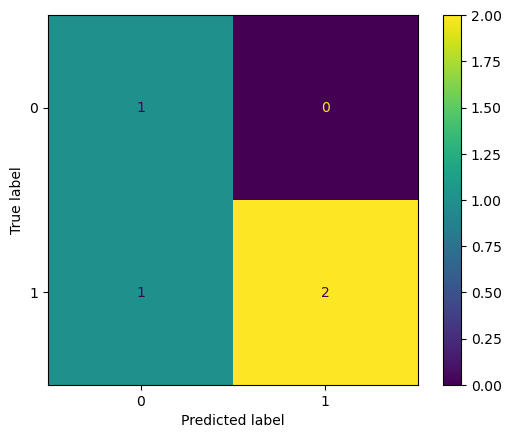

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred);
#ConfusionMatrixDisplay.from_estimator(model, X_test, y_test);

**Evaluation Metrics:**


$\text{Accuracy} \hspace{0.5cm} = \hspace{0.5cm} \large \frac{TP + TN}{TP + TN + FP + FN}$

$\text{Precision} \hspace{0.5cm} = \hspace{0.1cm} \large \frac{TP}{TP + FP}$


$\text{Recall} \hspace{0.9cm} = \hspace{0.1cm} \large \frac{TP}{TP + FN}$

$ F1 \hspace{1.4cm} = \hspace{0.1cm} \large \frac{2}{\frac{1}{P}+\frac{1}{R}} \hspace{0.6cm} \small= \hspace{0.1cm} \large \frac{2PR}{P+R}$


In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy score: ", accuracy)
print("Precision score: ", precision)
print("Recall score: ", recall)
print("F1 score: ", f1)
print("\n Classification Report:\n", classification_report(y_test, y_pred))

Accuracy score:  0.75
Precision score:  1.0
Recall score:  0.6666666666666666
F1 score:  0.8

 Classification Report:
               precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.67      0.80         3

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4



# f. Carry out Prediction of New Sentences
- **`youtube lectures are great source of learning`**

In [63]:
new_doc = ["youtube lectures are great source of learning"]
new_vector = cv.transform(new_doc) 
new_vector.toarray()

array([[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]])

In [64]:
y_hat = model.predict(new_vector)
y_hat

array([1])

- **`i am sick and do not want to stay in this house`**

In [65]:
new_doc = ["i am sick and do not want to stay in this house"]
new_vector = cv.transform(new_doc) 
y_hat = model.predict(new_vector)
y_hat

array([0])

# Task To Do

- SMS Spam Collection Dataset available at UCI repository: https://archive-beta.ics.uci.edu/ml/datasets/sms+spam+collection

In [66]:
import pandas as pd
df = pd.read_csv('datasets/smsspamcollection', sep='\t', header=None, names=['label', 'text'])
df

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
